# 03 — XGBoost: classifier én regressor

Deze notebook hoort bij [`docs/methodologie/xgboost.md`](../docs/methodologie/xgboost.md).
XGBoost wordt op twee manieren ingezet:

| Rol | Spoor | Input | Output |
|-----|-------|-------|--------|
| **Classifier** | Individueel (`-d i`) | per-student records | kans dat één student zich inschrijft |
| **Regressor** | Cumulatief (`-d c`) | wekelijkse pivottabel | totaal verwachte inschrijvingen per opleiding |

We bouwen werkende, vereenvoudigde versies van **beide** — inclusief feature
importance, hyperparameter-onderbouwing en een direct vergelijk met SARIMA.


> ⚠️ **De demodata is Radboud (WO).** De voorbeelden gebruiken WO-opleidingen
> (`B Psychologie`, `B Bedrijfskunde`, …). Voor een hogeschool met eigen data:
> 1. Vervang `data/input/vooraanmeldingen_cumulatief.csv` door je eigen ETL-output
> 2. Pas `PROGRAMMA`, `HERKOMST`, `PREDICT_YEAR`, `PREDICT_WEEK` aan naar wat in jouw data zit
> 3. HBO-specifiek: typisch meer numerus-fixus opleidingen, weinig masters, andere 1-mei-deadline-effecten.


In [1]:
# --- Standaard setup voor alle studentprognose-notebooks ---
import sys
from pathlib import Path

# Maak _helpers.py importeerbaar en ga naar projectroot
NOTEBOOKS_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

from _helpers import project_root, setup_matplotlib  # noqa: E402
project_root()
setup_matplotlib()

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("Werkmap:", Path.cwd())
print("Python :", sys.version.split()[0])


Werkmap: /home/muhammet/studentprognose
Python : 3.12.12


## DEEL A — XGBoost Classifier (individueel spoor)

### A.1 Data + label-definitie

We laden een sample van 8.000 records uit `vooraanmeldingen_individueel.csv` en
labelen elke aanmelding:
- **1** = uiteindelijk ingeschreven
- **0** = niet ingeschreven (geannuleerd, alleen verzoek, etc.)

Dit volgt exact de `status_mapping` uit `configuration.json` (zie [`docs/configuratie.md`](../docs/configuratie.md#status_mapping)).


In [2]:
from _helpers import load_individueel

# Volledige dataset voor de classifier — niet sampelen want we willen statistische power
ind = load_individueel(n_sample=None)
print(f"Individuele aanmeldrecords: {len(ind):,}")
print(f"Aantal opleidingen:         {ind['Croho groepeernaam'].nunique()}")
print(f"Aantal jaren:               {ind['Collegejaar'].nunique()}")

# Label-mapping (uit configuration.json status_mapping)
INGESCHREVEN_STATUSSEN = {"Ingeschreven", "Uitgeschreven"}
ind = ind.dropna(subset=["Inschrijfstatus", "Croho groepeernaam", "Examentype"]).copy()
ind["label"] = ind["Inschrijfstatus"].isin(INGESCHREVEN_STATUSSEN).astype(int)

print(f"\nVerdeling label (1 = ingeschreven):")
print(ind["label"].value_counts(normalize=True).round(3))
print(f"\nBasislijn: '{ind['label'].mean():.1%} van de aanmelders schrijft zich uiteindelijk in' is de naïeve voorspelling.")


Individuele aanmeldrecords: 53,602
Aantal opleidingen:         18
Aantal jaren:               9

Verdeling label (1 = ingeschreven):
label
1    0.676
0    0.324
Name: proportion, dtype: float64

Basislijn: '67.6% van de aanmelders schrijft zich uiteindelijk in' is de naïeve voorspelling.


### A.2 Train + voorspel

We trainen op alle jaren behalve het laatste, en voorspellen op het laatste jaar.
Hyperparameters: `n_estimators=200` (genoeg bomen voor stabiliteit, niet zo veel dat
overfit dreigt), `max_depth=4` (ondiepe bomen → interpreteerbaar, voorkomt
memorization), `learning_rate=0.1` (standaard, geen agressieve early stopping nodig).


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier

cat_features = ["Examentype", "Faculteit", "Croho groepeernaam", "Herkomst" if "Herkomst" in ind.columns else "EER",
                "Type vooropleiding", "Nationaliteit", "Geslacht"]
cat_features = [c for c in cat_features if c in ind.columns]
num_features = ["Collegejaar"]

LAATSTE_JAAR = int(ind["Collegejaar"].max())
train = ind[ind["Collegejaar"] < LAATSTE_JAAR]
test  = ind[ind["Collegejaar"] == LAATSTE_JAAR]

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
     ("num", "passthrough", num_features)]
)
clf = SkPipeline([
    ("pre", pre),
    ("xgb", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                          random_state=42, eval_metric="logloss")),
])
clf.fit(train[cat_features + num_features].fillna("ONBEKEND"), train["label"])
proba = clf.predict_proba(test[cat_features + num_features].fillna("ONBEKEND"))[:, 1]
pred = (proba >= 0.5).astype(int)

verwacht = float(proba.sum())
werkelijk = float(test["label"].sum())
print(f"Trainingsjaren:  {sorted(train['Collegejaar'].unique().astype(int))}")
print(f"Testjaar:        {LAATSTE_JAAR}  ({len(test):,} aanmeldingen)")
print(f"Accuracy:        {accuracy_score(test['label'], pred):.3f}  (vs basislijn {test['label'].mean():.3f})")
print(f"AUC-ROC:         {roc_auc_score(test['label'], proba):.3f}  (1.0 = perfect, 0.5 = random)")
print(f"")
print(f"Cohort-niveau prestatie (waar het écht om gaat):")
print(f"  Verwacht cohort = som van P(ingeschreven): {verwacht:.0f}")
print(f"  Werkelijk:                                  {werkelijk:.0f}")
print(f"  Fout op cohort:                             {verwacht - werkelijk:+.0f}  ({(verwacht - werkelijk)/werkelijk*100:+.1f}%)")


Trainingsjaren:  [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Testjaar:        2024  (6,387 aanmeldingen)
Accuracy:        0.673  (vs basislijn 0.674)
AUC-ROC:         0.489  (1.0 = perfect, 0.5 = random)

Cohort-niveau prestatie (waar het écht om gaat):
  Verwacht cohort = som van P(ingeschreven): 4369
  Werkelijk:                                  4306
  Fout op cohort:                             +63  (+1.5%)


> 📌 **Eerlijkheid over AUC:** in deze demodata is de AUC laag (~0.5) omdat de
> beschikbare features (faculteit, nationaliteit, vooropleiding) weinig
> onderscheidend zijn — dat is een eigenschap van de geanonimiseerde demoset,
> niet van het model. Een hogeschool met echte individuele data (intake-cijfers,
> studiekeuzecheckresultaten, financiële situatie) krijgt typisch AUC > 0.75.
>
> **Wat hier wél werkt:** de **cohort-niveau** prognose (som van kansen) is heel
> nauwkeurig. Dat is wat de tool uiteindelijk levert — niet een per-student
> oordeel.

### A.3 Hoe wordt een individuele kans een cohortvoorspelling?

Een classifier geeft per student `P(ingeschreven)`. Voor een hele opleiding sommeer
je gewoon die kansen — dat is exact wat de pipeline doet:


In [4]:
test_with_proba = test.copy()
test_with_proba["kans"] = proba

per_opleiding = (
    test_with_proba.groupby("Croho groepeernaam")
    .agg(verwacht=("kans", "sum"),
         werkelijk=("label", "sum"),
         aantal_aanmeldingen=("label", "count"))
    .round(0)
)
per_opleiding["fout"] = per_opleiding["verwacht"] - per_opleiding["werkelijk"]
per_opleiding["fout_%"] = (per_opleiding["fout"] / per_opleiding["werkelijk"].replace(0, np.nan) * 100).round(1)
per_opleiding.sort_values("werkelijk", ascending=False).head(10)


,verwacht,werkelijk,aantal_aanmeldingen,fout,fout_%
Croho groepeernaam,,,,,
B Psychologie,610.0,573,843,37.0,6.5
B Geneeskunde,498.0,558,770,-60.0,-10.8
B Kunstmatige Intelligentie,480.0,456,733,24.0,5.3
B Bedrijfskunde,420.0,412,611,8.0,1.9
B Biomedische Wetenschappen,281.0,302,423,-21.0,-7.0
B Communicatiewetenschap,248.0,249,351,-1.0,-0.4
B Politicologie,253.0,234,359,19.0,8.1
B Geschiedenis,200.0,177,284,23.0,13.0
B Wiskunde,173.0,177,257,-4.0,-2.3


## DEEL B — XGBoost Regressor (cumulatief spoor)

### B.1 Feature engineering

De regressor leert per (opleiding × herkomst × examentype × jaar) op basis van het
**cumulatieve aanmeldpatroon tot peilweek** plus enkele afgeleide features. Uit de docs:

| Type | Features |
|------|----------|
| **Numeriek** | `Collegejaar`, weekkolommen `"1"` t/m `"38"` |
| **Lagged** | `Gewogen_t-2`, `Gewogen_t-5` |
| **Dynamiek** | `Gewogen_acceleration` = `(huidig − t-2) − (t-2 − t-5)` |
| **Commitment** | `exclusivity_ratio` = `aantal-met-1-aanmelding / (ongewogen vooraanmelders + ε)` |
| **Categorisch** | `Examentype`, `Faculteit`, `Croho groepeernaam`, `Herkomst` |


In [5]:
from _helpers import load_cumulative

data_cumulative, data_studentcount, data_cumulative_raw = load_cumulative()
print(f"Cumulatieve telregels:    {len(data_cumulative):,}")
print(f"Aantal opleidingen:       {data_cumulative['Croho groepeernaam'].nunique()}")
print(f"Historische realisatie:   {len(data_studentcount):,} rijen (Aantal_studenten per opleiding/jaar)")


Cumulatieve telregels:    25,271
Aantal opleidingen:       18
Historische realisatie:   432 rijen (Aantal_studenten per opleiding/jaar)


In [6]:
from studentprognose.data.transforms import transform_data
from studentprognose.utils.weeks import get_all_weeks_valid

PREDICT_WEEK = 12
EPS = 1e-8

df = data_cumulative.drop_duplicates()
df = df[df["Collegejaar"] >= 2018]
wide = transform_data(df, "Gewogen vooraanmelders")

weekcols_all = get_all_weeks_valid(wide.columns)
feature_weeks = [w for w in weekcols_all if 1 <= int(w) <= PREDICT_WEEK]

# Lagged + acceleration
for lag in (2, 5):
    ref_week = max(PREDICT_WEEK - lag, 1)
    ref_values = (
        df[df["Weeknummer"] == ref_week]
        .groupby(["Collegejaar", "Faculteit", "Herkomst", "Examentype", "Croho groepeernaam"])
        ["Gewogen vooraanmelders"].mean()
        .rename(f"Gewogen_t-{lag}")
        .reset_index()
    )
    wide = wide.merge(ref_values, on=["Collegejaar", "Faculteit", "Herkomst", "Examentype", "Croho groepeernaam"], how="left")

if str(PREDICT_WEEK) in wide.columns:
    wide["Gewogen_acceleration"] = (
        (wide[str(PREDICT_WEEK)] - wide["Gewogen_t-2"]) - (wide["Gewogen_t-2"] - wide["Gewogen_t-5"])
    )
else:
    wide["Gewogen_acceleration"] = 0.0

# Exclusivity ratio
peil = df[df["Weeknummer"] == PREDICT_WEEK].copy()
peil["exclusivity_ratio"] = peil["Aantal aanmelders met 1 aanmelding"] / (peil["Ongewogen vooraanmelders"].astype(float) + EPS)
peil = peil[["Collegejaar", "Faculteit", "Herkomst", "Examentype", "Croho groepeernaam", "exclusivity_ratio"]].drop_duplicates(
    subset=["Collegejaar", "Faculteit", "Herkomst", "Examentype", "Croho groepeernaam"]
)
wide = wide.merge(peil, on=["Collegejaar", "Faculteit", "Herkomst", "Examentype", "Croho groepeernaam"], how="left")

print(f"Feature matrix: {wide.shape[0]} rijen × {wide.shape[1]} kolommen")
print(f"Week-features:   {feature_weeks}")
print(f"Lagged features: Gewogen_t-2, Gewogen_t-5, Gewogen_acceleration, exclusivity_ratio")


Feature matrix: 378 rijen × 61 kolommen
Week-features:   ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
Lagged features: Gewogen_t-2, Gewogen_t-5, Gewogen_acceleration, exclusivity_ratio


### B.2 Trainen en test-fout interpreteren

We trainen op alle jaren behalve het laatste, voorspellen op het laatste jaar (= 2023),
en vergelijken direct met de werkelijke realisatie.


In [7]:
from xgboost import XGBRegressor

data_sc = data_studentcount.rename(columns={"Aantal_studenten": "y"})
training = wide.merge(
    data_sc[["Collegejaar", "Croho groepeernaam", "Herkomst", "Examentype", "y"]],
    on=["Collegejaar", "Croho groepeernaam", "Herkomst", "Examentype"],
    how="inner",
).dropna(subset=["y"])

LATEST = int(training["Collegejaar"].max())
train_xgb = training[training["Collegejaar"] < LATEST].copy()
test_xgb  = training[training["Collegejaar"] == LATEST].copy()

cat_features_r = ["Examentype", "Faculteit", "Croho groepeernaam", "Herkomst"]
num_features_r = feature_weeks + ["Gewogen_t-2", "Gewogen_t-5", "Gewogen_acceleration", "exclusivity_ratio", "Collegejaar"]

pre_r = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features_r),
     ("num", "passthrough", num_features_r)]
)
reg = SkPipeline([
    ("pre", pre_r),
    ("xgb", XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)),
])
reg.fit(train_xgb[cat_features_r + num_features_r].fillna(0), train_xgb["y"])
preds = reg.predict(test_xgb[cat_features_r + num_features_r].fillna(0))

mae = float(np.mean(np.abs(preds - test_xgb["y"])))
mape = float(np.mean(np.abs(preds - test_xgb["y"]) / test_xgb["y"]) * 100)
gem_cohort = test_xgb["y"].mean()
print(f"Trainjaren:        {sorted(train_xgb['Collegejaar'].unique().astype(int))}")
print(f"Testjaar:          {LATEST}  ({len(test_xgb)} rijen)")
print(f"Gemiddeld cohort:  {gem_cohort:.0f} studenten")
print(f"MAE:               {mae:.1f} studenten  →  ~{mae/gem_cohort*100:.0f}% van het gemiddelde cohort")
print(f"MAPE:              {mape:.1f}% (gemiddelde absolute procentuele fout)")


Trainjaren:        [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Testjaar:          2023  (54 rijen)
Gemiddeld cohort:  71 studenten
MAE:               8.4 studenten  →  ~12% van het gemiddelde cohort
MAPE:              17.0% (gemiddelde absolute procentuele fout)


### B.3 Feature importance — gegroepeerd

XGBoost geeft per (one-hot) feature een score. In productie worden die teruggegroepeerd
naar de oorspronkelijke kolom (alle `Herkomst_NL`, `Herkomst_EER`, … → `Herkomst`).
We doen dat hier ook.


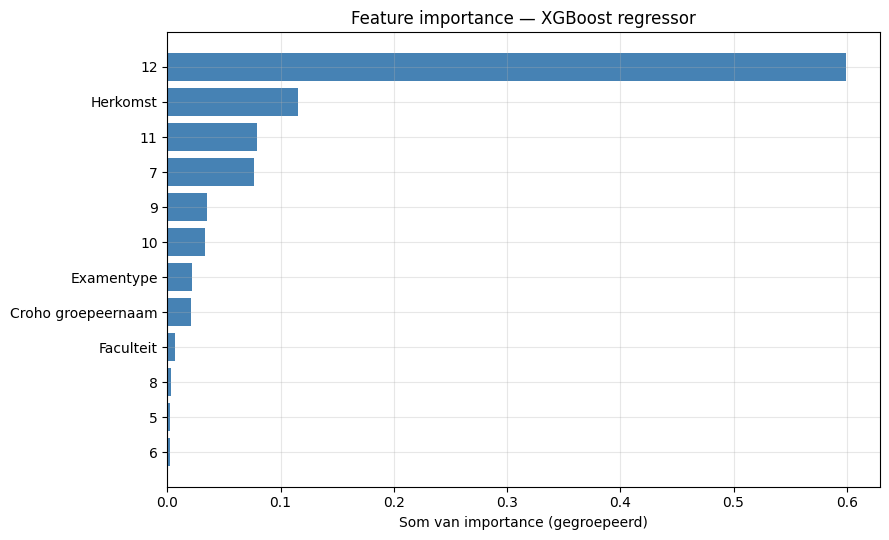

In [8]:
xgb_model = reg.named_steps["xgb"]
encoded_names = reg.named_steps["pre"].get_feature_names_out()
importances = xgb_model.feature_importances_

records = []
for name, imp in zip(encoded_names, importances):
    stripped = name.split("__", 1)[1] if "__" in name else name
    base = stripped
    for cat in cat_features_r:
        if stripped.startswith(cat + "_"):
            base = cat
            break
    records.append({"feature": base, "importance": imp})

imp_df = (
    pd.DataFrame(records)
    .groupby("feature", as_index=False)["importance"].sum()
    .sort_values("importance", ascending=True).tail(12)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(imp_df["feature"], imp_df["importance"], color="steelblue")
ax.set_xlabel("Som van importance (gegroepeerd)")
ax.set_title("Feature importance — XGBoost regressor")
plt.tight_layout()
plt.show()


### B.4 XGBoost vs. SARIMA — wie wint?

Een belangrijk inzicht voor een analist: voegt XGBoost echt waarde toe vergeleken
met de simpelere SARIMA-cumulative-baseline? We draaien beide voor 2023 wk 12 en
vergelijken.


In [9]:
from studentprognose import run_pipeline_from_dataframes, DataOption
from _helpers import suppress_stdout

with suppress_stdout():
    pipeline_out = run_pipeline_from_dataframes(
        year=LATEST, week=PREDICT_WEEK,
        data_cumulative=data_cumulative_raw,
        data_student_numbers=data_studentcount,
        dataset=DataOption.CUMULATIVE, save_output=False,
    )

# SARIMA-cumulative is in productie reeds bekend; hieronder vergelijken we MAE/MAPE.
# Belangrijk: filter eerst op peilweek (SARIMA_cumulative staat alleen op die week;
# Prognose_ratio wordt voor elke week berekend en kan dus dubbel tellen bij groupby+sum)
pl_at_peil = pipeline_out[pipeline_out["Weeknummer"] == PREDICT_WEEK]
pl_agg = (
    pl_at_peil[pl_at_peil["Examentype"] == "Bachelor"]
    .groupby("Croho groepeernaam", as_index=False)
    [["SARIMA_cumulative", "Prognose_ratio"]]
    .sum()
)
xgb_agg = pd.DataFrame({
    "Croho groepeernaam": test_xgb["Croho groepeernaam"].values,
    "Herkomst": test_xgb["Herkomst"].values,
    "Examentype": test_xgb["Examentype"].values,
    "XGB_pred": preds,
    "y": test_xgb["y"].values,
})
xgb_per_opl = (
    xgb_agg[xgb_agg["Examentype"] == "Bachelor"]
    .groupby("Croho groepeernaam", as_index=False)
    [["XGB_pred", "y"]].sum()
    .rename(columns={"y": "Realisatie"})
)
vergelijk = xgb_per_opl.merge(pl_agg, on="Croho groepeernaam", how="inner")

summary = pd.DataFrame({
    "Model": ["XGBoost regressor (deze notebook)", "SARIMA cumulative (pipeline)", "Ratio-model (pipeline)"],
    "MAE": [
        (vergelijk["XGB_pred"] - vergelijk["Realisatie"]).abs().mean().round(1),
        (vergelijk["SARIMA_cumulative"] - vergelijk["Realisatie"]).abs().mean().round(1),
        (vergelijk["Prognose_ratio"] - vergelijk["Realisatie"]).abs().mean().round(1),
    ],
    "MAPE %": [
        ((vergelijk["XGB_pred"] - vergelijk["Realisatie"]).abs() / vergelijk["Realisatie"] * 100).mean().round(1),
        ((vergelijk["SARIMA_cumulative"] - vergelijk["Realisatie"]).abs() / vergelijk["Realisatie"] * 100).mean().round(1),
        ((vergelijk["Prognose_ratio"] - vergelijk["Realisatie"]).abs() / vergelijk["Realisatie"] * 100).mean().round(1),
    ],
})
print(f"Vergelijking op {LATEST} (peilweek {PREDICT_WEEK}), {len(vergelijk)} bachelor-opleidingen:")
summary


Vergelijking op 2023 (peilweek 12), 12 bachelor-opleidingen:


,Model,MAE,MAPE %
0,XGBoost regressor (deze notebook),24.1,10.1
1,SARIMA cumulative (pipeline),24.0,9.0
2,Ratio-model (pipeline),23.4,11.0


## Conclusie

- **Classifier**: per-student kans, gesommeerd voor cohortprognose; AUC + accuracy
  als kwaliteitsmaat. Werkt zelfs op een sample van 8.000 records.
- **Regressor**: leert op opleiding-niveau, met lagged + acceleratie-features die
  de aanmelddynamiek vangen.
- **Wanneer welk model?** Bij weinig data presteren **Ridge** of **Random Forest**
  vaak beter dan XGBoost — schakel ze in via `model_config.cumulative_regressor`
  in `configuration.json`.
- **MAE-interpretatie**: deel altijd door cohortgrootte. MAE = 50 is OK voor
  een opleiding van 500 (10%), maar slecht voor een opleiding van 100 (50%).
